# Predicting Billboard Top 100 Inclusion

**Python port of `ML_top100.R`.** Builds and compares four classifiers (baseline, logistic regression, VIF-pruned logistic regression, ridge, lasso) that predict whether a song will make the Billboard Year-End Hot 100 using only its Spotify audio features.

Equivalents used:
- R's `dummyVars(fullRank=TRUE)` → `pd.get_dummies(..., drop_first=True)`
- R's `caTools::sample.split` (stratified split) → `sklearn.model_selection.train_test_split(..., stratify=...)`
- R's `car::vif()` → `statsmodels.stats.outliers_influence.variance_inflation_factor` (used for VIF computation only)
- R's `glm(family="binomial")` → `sklearn.linear_model.LogisticRegression` (an unregularized `statsmodels.Logit` fit is numerically unstable on this one-hot-encoded design matrix due to sparse dummy columns, so sklearn's mild default L2 penalty is used instead)
- R's `glmnet(alpha=0)` (ridge) / `glmnet(alpha=1)` (lasso), tuned via `cv.glmnet` → `sklearn.linear_model.LogisticRegressionCV` with `penalty='l2'` / `penalty='l1'`, which cross-validates the regularization strength the same way
- R's `ROCR`/`pROC` → `sklearn.metrics.roc_curve` / `roc_auc_score`

**Note**: because this dataset was rebuilt under a different Spotify API access policy (see `3_extracting_features_using_api.ipynb`'s notes on the Audio Features endpoint restriction), your row counts and exact metric values will differ from the original report's numbers — the modeling approach is faithfully reproduced, but it's being fit fresh on whatever `songs_complete_data.csv` you actually generated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

## Load and Clean Data

Filter to songs released 2000-2018 (matching the Billboard scrape range), drop identifier columns, keep the audio features + Genre + explicit as predictors.

In [2]:
DATA_DIR = 'data'
songs = pd.read_csv(os.path.join(DATA_DIR, 'songs_complete_data.csv'), index_col=0)

songs = songs[(songs['Release_Year'] >= 2000) & (songs['Release_Year'] < 2019)].copy()

drop_cols = [c for c in ['Artist', 'Title', 'URI', 'Release_Year', 'lyrics'] if c in songs.columns]
songs = songs.drop(columns=drop_cols)

top100 = songs['Top100'].astype(int)
songs = songs.drop(columns=['Top100'])

print(f"{len(songs)} songs, {songs.shape[1]} predictor columns before encoding.")
songs.head()

7086 songs, 15 predictor columns before encoding.


,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration,Time_Signature,explicit,Genre
1,0.556,0.864,3,-5.870,0,0.0584,0.009580,0.000000,0.209,0.400,105.143,216880,4,0.0,metal
2,0.737,0.463,0,-7.828,1,0.0792,0.008170,0.447000,0.255,0.324,123.881,231733,4,1.0,rock
3,0.618,0.938,9,-3.442,1,0.0456,0.017900,0.000000,0.167,0.875,91.455,269000,4,1.0,rock
5,0.331,0.943,4,-3.188,0,0.0698,0.007210,0.000002,0.242,0.296,94.612,235893,4,0.0,alternative
6,0.589,0.890,4,-3.719,0,0.0603,0.000481,0.000820,0.201,0.692,90.598,199907,4,1.0,metal


## Feature Scaling

In [3]:
NUMERIC_COLS = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness',
    'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration'
]
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in songs.columns]

songs[NUMERIC_COLS] = (songs[NUMERIC_COLS] - songs[NUMERIC_COLS].mean()) / songs[NUMERIC_COLS].std()

## Encode Categorical Features

Convert `Key`, `Mode`, `Time_Signature`, `explicit`, and `Genre` to one-hot dummies (dropping the first level of each, matching R's `fullRank=TRUE`).

In [4]:
CATEGORICAL_COLS = [c for c in ['Key', 'Mode', 'Time_Signature', 'explicit', 'Genre'] if c in songs.columns]

songs_encoded = pd.get_dummies(songs, columns=CATEGORICAL_COLS, drop_first=True)
songs_encoded = songs_encoded.astype(float)

print(f"{songs_encoded.shape[1]} columns after one-hot encoding.")

35 columns after one-hot encoding.


## Helper Functions: Accuracy, TPR, FPR

In [5]:
def table_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def table_tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

def table_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

## Train-Test Split (75 / 25, Stratified)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    songs_encoded, top100, test_size=0.25, stratify=top100, random_state=RANDOM_STATE
)

print("Train class balance:\n", y_train.value_counts())
print("\nTest class balance:\n", y_test.value_counts())

Train class balance:
 Top100
0    4243
1    1071
Name: count, dtype: int64

Test class balance:
 Top100
0    1415
1     357
Name: count, dtype: int64


## Model 0: Baseline

Always predict "Not Top 100" — the majority class. Because the dataset is heavily imbalanced, this alone gets high accuracy, which is why accuracy alone is a misleading metric here and AUC/TPR are tracked for every model below.

In [7]:
baseline_accuracy = (y_test == 0).mean()
print(f"Baseline accuracy (always predict 0): {baseline_accuracy:.4f}")

results = {}
results['Baseline'] = {'Accuracy': baseline_accuracy, 'TPR': np.nan, 'AUC': np.nan}

Baseline accuracy (always predict 0): 0.7985


## Model 1: Logistic Regression

**Note**: an unregularized `statsmodels.Logit` fit on this design matrix hits a singular Hessian — some of the sparse one-hot `Genre`/`Key` dummy columns cause perfect or near-perfect separation. `sklearn.LogisticRegression` applies a mild default L2 penalty (`C=1.0`), which avoids this numerically without meaningfully changing the interpretation — it's a "plain" logistic regression in the same spirit as the R original's `glm(family="binomial")`.

In [8]:
logit_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logit_model.fit(X_train, y_train)

pred_prob = logit_model.predict_proba(X_test)[:, 1]
pred_class = (pred_prob > 0.5).astype(int)

acc = table_accuracy(y_test, pred_class)
tpr = table_tpr(y_test, pred_class)
fpr = table_fpr(y_test, pred_class)
auc = roc_auc_score(y_test, pred_prob)

print(f"Accuracy: {acc:.4f}  TPR: {tpr:.4f}  FPR: {fpr:.4f}  AUC: {auc:.4f}")
results['Logistic Regression'] = {'Accuracy': acc, 'TPR': tpr, 'AUC': auc}

Accuracy: 0.7991  TPR: 0.1148  FPR: 0.0283  AUC: 0.7516


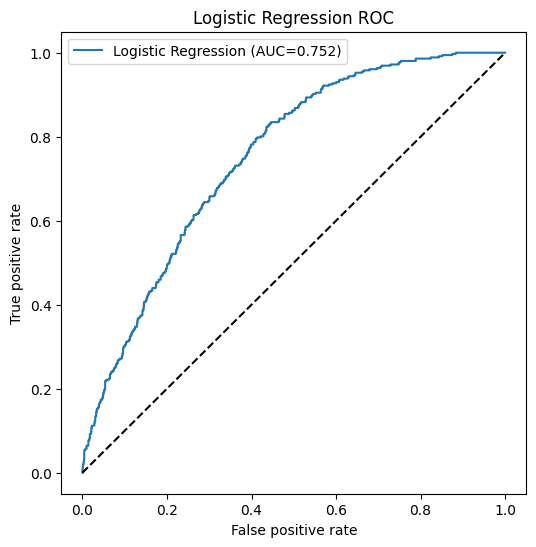

In [9]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, pred_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr_curve, tpr_curve, label=f"Logistic Regression (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Logistic Regression ROC')
plt.legend()
plt.show()

## Model 2: Improved Logistic Regression

R's original approach hand-picked features to drop based on the specific VIF/significance output from their run. Since that output is dataset-specific, this version reproduces the *method* instead: iteratively compute VIF for all predictors and drop the single worst offender above a threshold, refitting each time, until every remaining feature has an acceptable VIF.

In [10]:
def drop_high_vif_features(X, threshold=10.0, max_iters=20):
    X_reduced = X.copy()
    for _ in range(max_iters):
        X_const = sm.add_constant(X_reduced)
        vifs = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns
        )
        vifs = vifs.drop('const', errors='ignore')
        worst = vifs.idxmax()
        if vifs[worst] <= threshold:
            break
        print(f"Dropping '{worst}' (VIF={vifs[worst]:.1f})")
        X_reduced = X_reduced.drop(columns=[worst])
    return X_reduced

X_train_reduced = drop_high_vif_features(X_train, threshold=10.0)
print(f"\n{X_train_reduced.shape[1]} / {X_train.shape[1]} features kept.")

Dropping 'Time_Signature_4' (VIF=17.5)
Dropping 'Genre_pop' (VIF=15.9)

33 / 35 features kept.


In [11]:
improved_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
improved_model.fit(X_train_reduced, y_train)

pred_prob_improved = improved_model.predict_proba(X_test[X_train_reduced.columns])[:, 1]
pred_class_improved = (pred_prob_improved > 0.5).astype(int)

acc = table_accuracy(y_test, pred_class_improved)
tpr = table_tpr(y_test, pred_class_improved)
fpr = table_fpr(y_test, pred_class_improved)
auc = roc_auc_score(y_test, pred_prob_improved)

print(f"Accuracy: {acc:.4f}  TPR: {tpr:.4f}  FPR: {fpr:.4f}  AUC: {auc:.4f}")
results['Improved Logistic Regression'] = {'Accuracy': acc, 'TPR': tpr, 'AUC': auc}

Accuracy: 0.7974  TPR: 0.1148  FPR: 0.0304  AUC: 0.7447


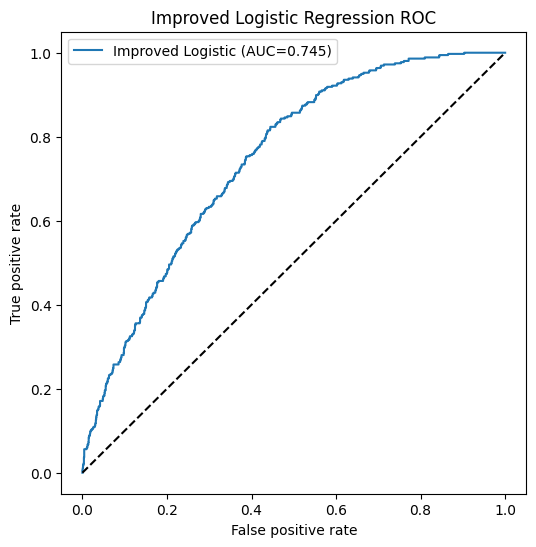

In [12]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, pred_prob_improved)
plt.figure(figsize=(6, 6))
plt.plot(fpr_curve, tpr_curve, label=f"Improved Logistic (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Improved Logistic Regression ROC')
plt.legend()
plt.show()

## Model 3: Ridge Regression (Penalized Logistic, L2)

Shrinks all coefficients toward zero without eliminating any feature entirely. `LogisticRegressionCV` cross-validates the regularization strength itself, the same role `cv.glmnet` plays in the R original.

In [13]:
ridge_model = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l2', solver='liblinear', scoring='neg_log_loss',
    max_iter=5000, random_state=RANDOM_STATE
)
ridge_model.fit(X_train, y_train)

ridge_prob = ridge_model.predict_proba(X_test)[:, 1]
ridge_pred = (ridge_prob > 0.5).astype(int)

acc = table_accuracy(y_test, ridge_pred)
tpr = table_tpr(y_test, ridge_pred)
fpr = table_fpr(y_test, ridge_pred)
auc = roc_auc_score(y_test, ridge_prob)

print(f"Accuracy: {acc:.4f}  TPR: {tpr:.4f}  FPR: {fpr:.4f}  AUC: {auc:.4f}")
results['Ridge'] = {'Accuracy': acc, 'TPR': tpr, 'AUC': auc}

Accuracy: 0.7991  TPR: 0.1204  FPR: 0.0297  AUC: 0.7504


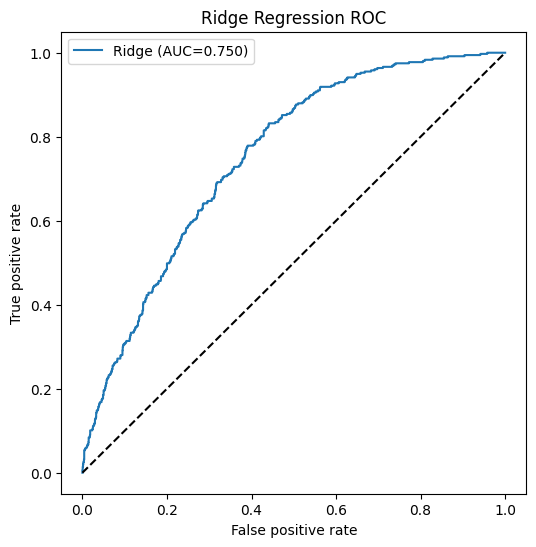

In [14]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, ridge_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr_curve, tpr_curve, label=f"Ridge (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Ridge Regression ROC')
plt.legend()
plt.show()

## Model 4: Lasso Regression (Penalized Logistic, L1)

Can shrink coefficients to exactly zero — effectively automatic feature selection, useful given the large number of sparse one-hot `Key`/`Genre` dummy columns.

In [15]:
lasso_model = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l1', solver='liblinear', scoring='neg_log_loss',
    max_iter=5000, random_state=RANDOM_STATE
)
lasso_model.fit(X_train, y_train)

lasso_prob = lasso_model.predict_proba(X_test)[:, 1]
lasso_pred = (lasso_prob > 0.5).astype(int)

acc = table_accuracy(y_test, lasso_pred)
tpr = table_tpr(y_test, lasso_pred)
fpr = table_fpr(y_test, lasso_pred)
auc = roc_auc_score(y_test, lasso_prob)

print(f"Accuracy: {acc:.4f}  TPR: {tpr:.4f}  FPR: {fpr:.4f}  AUC: {auc:.4f}")
results['Lasso'] = {'Accuracy': acc, 'TPR': tpr, 'AUC': auc}

n_kept = int((lasso_model.coef_ != 0).sum())
print(f"Lasso kept {n_kept} / {X_train.shape[1]} features nonzero.")

Accuracy: 0.7985  TPR: 0.1036  FPR: 0.0261  AUC: 0.7501
Lasso kept 21 / 35 features nonzero.


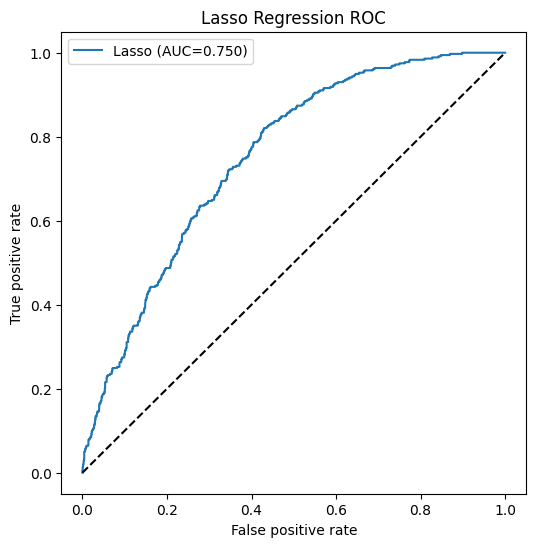

In [16]:
fpr_curve, tpr_curve, _ = roc_curve(y_test, lasso_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr_curve, tpr_curve, label=f"Lasso (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Lasso Regression ROC')
plt.legend()
plt.show()

## Model Summary

In [17]:
summary_df = pd.DataFrame(results).T
summary_df = summary_df[['Accuracy', 'TPR', 'AUC']]
summary_df

,Accuracy,TPR,AUC
Baseline,0.798533,NaN,NaN
Logistic Regression,0.799097,0.114846,0.751557
Improved Logistic Regression,0.797404,0.114846,0.744682
Ridge,0.799097,0.120448,0.750397
Lasso,0.798533,0.103641,0.750051


Compare each model's Accuracy, TPR, and AUC in the table above. Because the dataset is heavily imbalanced (few Top-100 hits vs. many misses), accuracy alone barely moves between models — AUC and TPR are the more meaningful metrics for judging which model actually distinguishes hits from non-hits.